In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 187s 12s/step - accuracy: 0.5800 - dice_score: 0.4173 - iou: 0.2646 - loss: 0.6893 - val_accuracy: 0.6633 - val_dice_score: 0.4169 - val_iou: 0.2633 - val_loss: 0.6663
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 183s 12s/step - accuracy: 0.6054 - dice_score: 0.4238 - iou: 0.2689 - loss: 0.6753 - val_accuracy: 0.7018 - val_dice_score: 0.4148 - val_iou: 0.2618 - val_loss: 0.6052
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 198s 12s/step - accuracy: 0.6511 - dice_score: 0.4099 - iou: 0.2592 - loss: 0.6464 - val_accuracy: 0.8801 - val_dice_score: 0.5016 - val_iou: 0.3348 - val_loss: 0.5260
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 202s 12s/step - accuracy: 0.6469 - dice_score: 0.4411 - iou: 0.2838 - loss: 0.6491 - val_accuracy: 0.8576 - val_dice_score: 0.5671 - val_iou: 0.3959 - val_loss: 0.4227
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 201s 12s/step - accuracy: 0.6505 - dice_score: 0.4332 - iou: 0.2777 - loss: 0.6250 - val_accuracy: 0.9114 - val_dice_score: 0.6258 - val_i

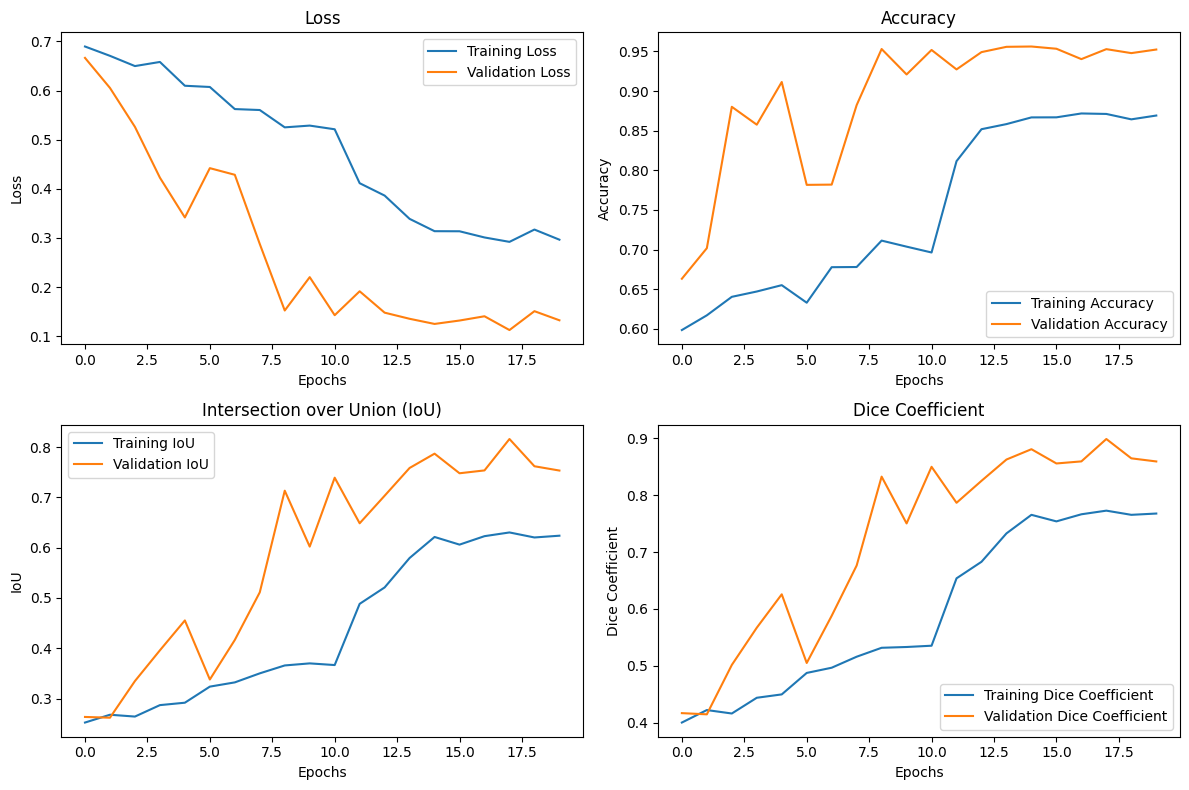

In [ ]:

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# Load data
def load_data(images_path, masks_path, target_size):
    images = []
    masks = []
    for img_name in os.listdir(images_path):
        # Load image
        img = load_img(os.path.join(images_path, img_name), target_size=target_size)
        img = img_to_array(img) / 255.0  # Normalize
        images.append(img)

        # Load mask
        mask_name = img_name.replace('.jpg', '.png')
        mask = load_img(os.path.join(masks_path, mask_name), target_size=target_size, color_mode="grayscale")
        mask = img_to_array(mask) / 255.0  # Normalize
        masks.append(mask)

    return np.array(images), np.array(masks)

# Data paths
images_path = "/content/drive/MyDrive/Optic Disc - Glaucoma/images"
masks_path = "/content/drive/MyDrive/Optic Disc - Glaucoma/masks"
target_size = (128, 128)

# Load dataset
images, masks = load_data(images_path, masks_path, target_size)

# Split dataset
X_train, X_val, y_train, y_val = train_test_split(images, masks, test_size=0.2, random_state=42)

# Augment data
def augment_data(images, masks):
    image_datagen = ImageDataGenerator(
        rotation_range=30,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.2,
        horizontal_flip=True,
        brightness_range=[0.8, 1.2]
    )

    mask_datagen = ImageDataGenerator(
        rotation_range=30,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.2,
        horizontal_flip=True
    )

    augmented_images = []
    augmented_masks = []

    for img, mask in zip(images, masks):
        img = img[np.newaxis, ...]  # Add batch dimension
        mask = mask[np.newaxis, ...]

        for img_aug, mask_aug in zip(image_datagen.flow(img, batch_size=1, seed=42),
                                     mask_datagen.flow(mask, batch_size=1, seed=42)):
            augmented_images.append(img_aug[0])
            augmented_masks.append(mask_aug[0])
            if len(augmented_images) >= len(images):  # Limit augmentations to match dataset size
                break

    return np.array(augmented_images), np.array(augmented_masks)

# Augment train data
X_train_aug, y_train_aug = augment_data(X_train, y_train)

# Combine original and augmented data
X_train_combined = np.concatenate((X_train, X_train_aug))
y_train_combined = np.concatenate((y_train, y_train_aug))

# Define U-Net model
def unet_model(input_size):
    inputs = layers.Input(input_size)

    # Downsampling
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = layers.Dropout(0.1)(c1)
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    # Bottleneck
    c4 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(p3)
    c4 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(c4)

    # Upsampling
    u5 = layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(c4)
    u5 = layers.concatenate([u5, c3])
    c5 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(u5)
    c5 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c5)

    u6 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = layers.concatenate([u6, c2])
    c6 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(u6)
    c6 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c6)

    u7 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = layers.concatenate([u7, c1])
    c7 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u7)
    c7 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c7)

    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c7)

    model = tf.keras.models.Model(inputs=[inputs], outputs=[outputs])
    return model

def iou(y_true, y_pred):
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
    iou = (intersection + 1e-15) / (union + 1e-15)
    return iou

def dice_score(y_true, y_pred):
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred)
    dice = (2. * intersection + 1e-15) / (union + 1e-15)
    return dice

# Compile model
input_size = (128, 128, 3)
model = unet_model(input_size)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', iou, dice_score])

# Train model
history = model.fit(
    X_train_combined, y_train_combined,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=8
)

# Save model
model.save("unet_model.h5")

# Plot Evaluation
def plot_training_history(history):
    plt.figure(figsize=(12, 8))

    # Plot Loss
    plt.subplot(2, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plot Accuracy
    plt.subplot(2, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot IoU
    plt.subplot(2, 2, 3)
    plt.plot(history.history['iou'], label='Training IoU')
    plt.plot(history.history['val_iou'], label='Validation IoU')
    plt.title('Intersection over Union (IoU)')
    plt.xlabel('Epochs')
    plt.ylabel('IoU')
    plt.legend()

    # Plot Dice Score
    plt.subplot(2, 2, 4)
    plt.plot(history.history['dice_score'], label='Training Dice Coefficient')
    plt.plot(history.history['val_dice_score'], label='Validation Dice Coefficient')
    plt.title('Dice Coefficient')
    plt.xlabel('Epochs')
    plt.ylabel('Dice Coefficient')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Display training results
plot_training_history(history)



1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


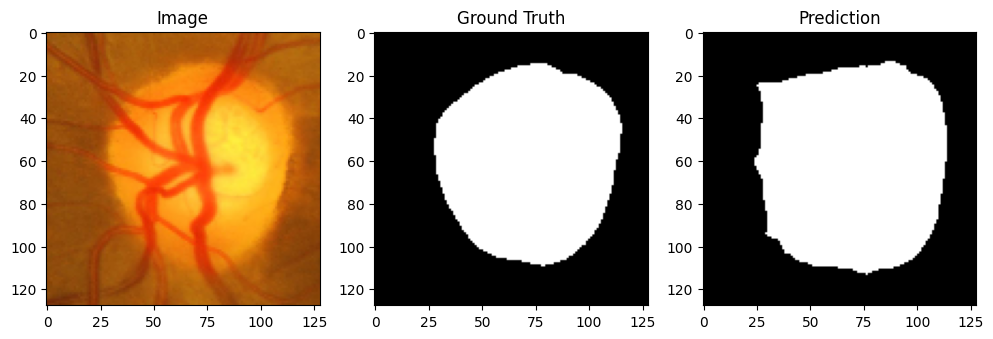

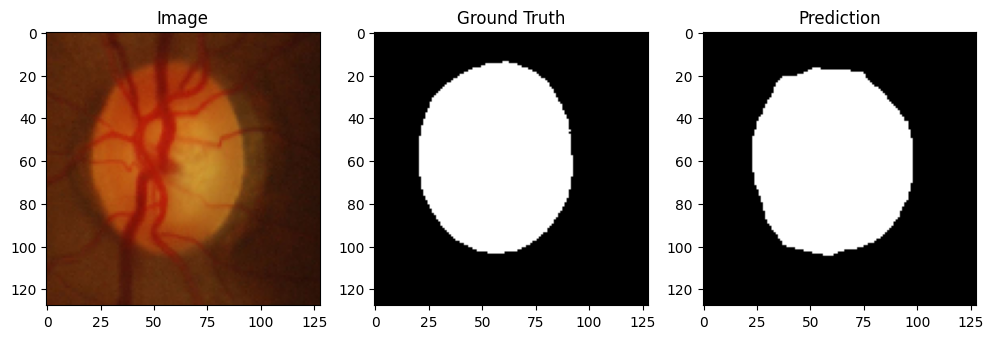

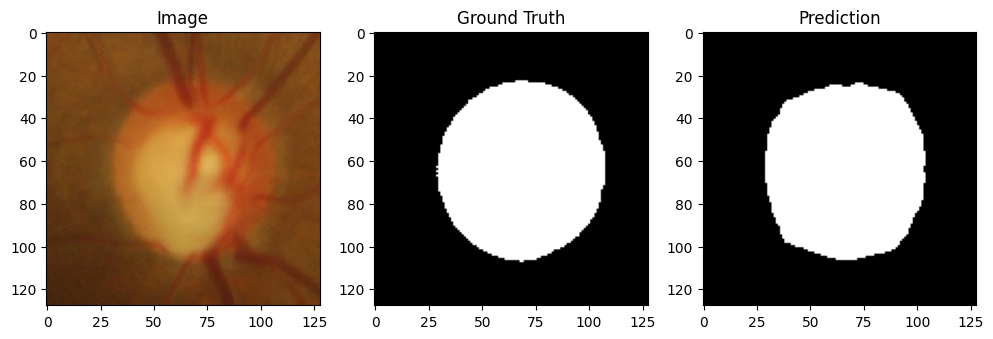

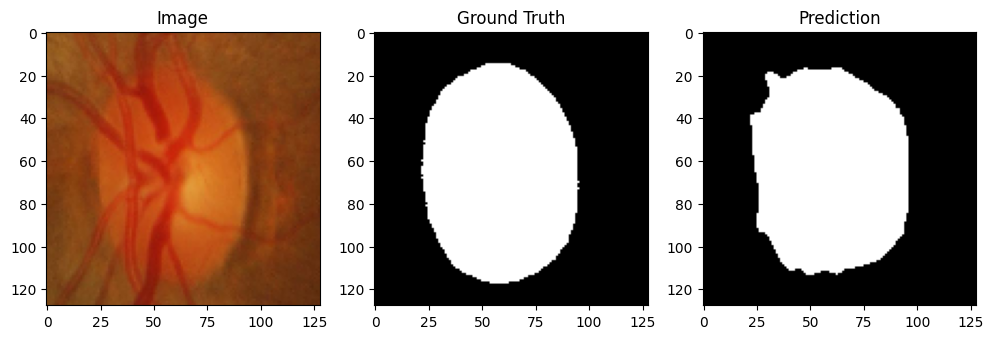

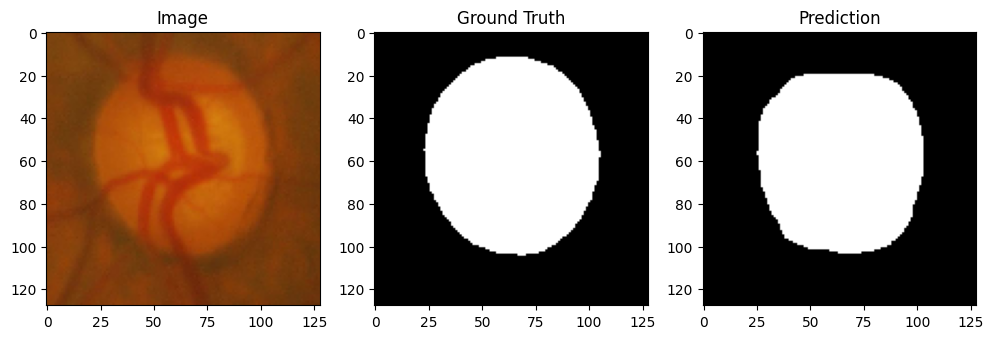

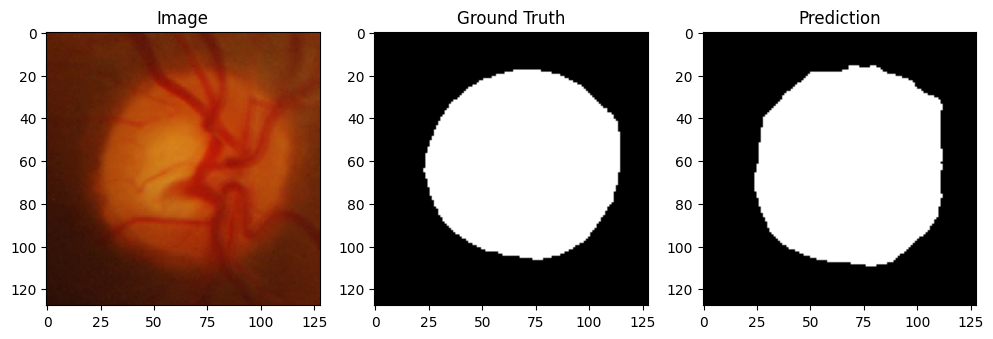

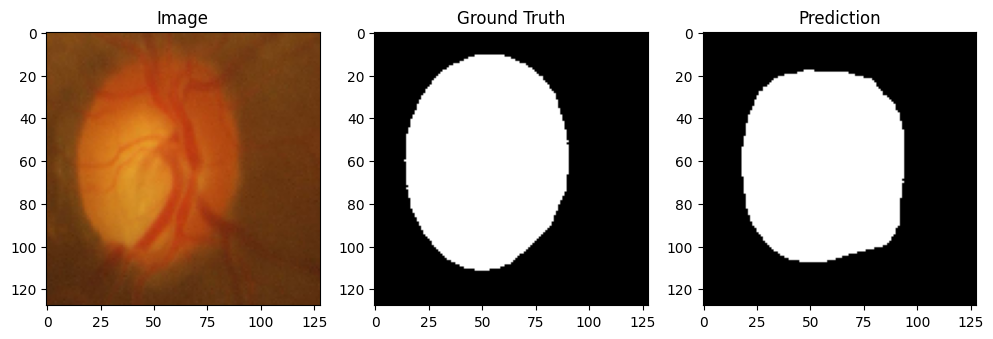

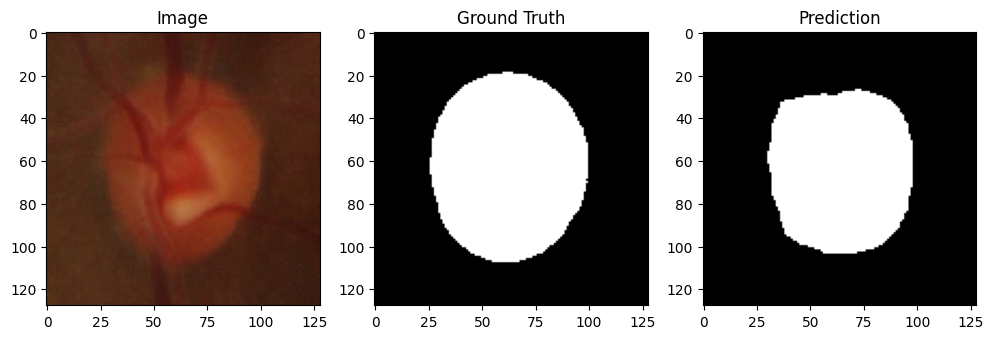

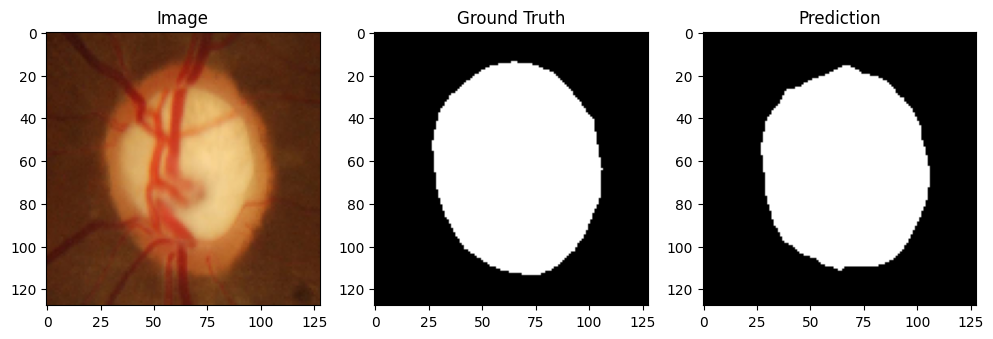

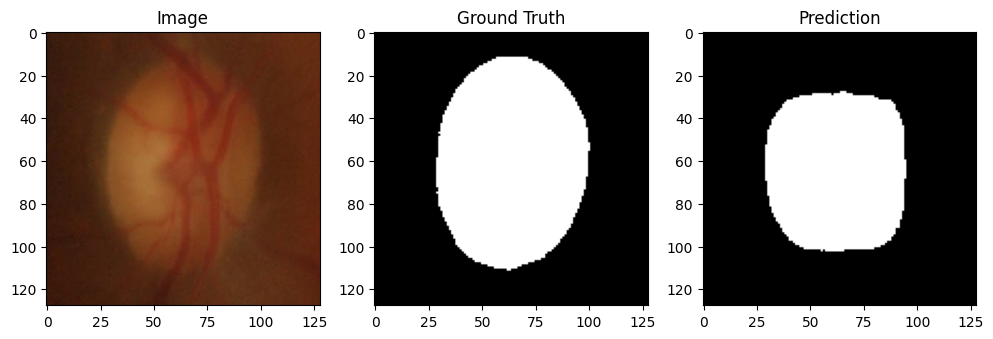

In [ ]:
# Tambahkan di awal file
from skimage.exposure import rescale_intensity

def process_predictions(predictions, threshold=0.45):
    """
    Enhance and process the predictions for better visualization.
    Arguments:
    - predictions: model predictions (numpy array).
    - threshold: threshold value for binarization.
    Returns:
    - Processed predictions.
    """

    # Normalize predictions to [0, 1]
    predictions = (predictions - predictions.min()) / (predictions.max() - predictions.min())

    # Apply threshold for binary mask
    binary_predictions = (predictions > threshold).astype(float)

    # Rescale intensity for better visualization
    enhanced_predictions = rescale_intensity(binary_predictions, in_range=(0, 1), out_range=(0, 255))

    return enhanced_predictions.astype(float)

# Modifikasi fungsi visualize_prediction
def visualize_prediction(model, X, y):
    predictions = model.predict(X)  # Model melakukan prediksi

    # **Tambahkan ini untuk memproses prediksi**
    predictions = process_predictions(predictions)  # Post-processing prediksi

    for i in range(10):  # Visualisasi 10 contoh pertama
        plt.figure(figsize=(12, 4))

        # Gambar asli
        plt.subplot(1, 3, 1)
        plt.title("Image")
        plt.imshow(X[i])

        # Ground Truth
        plt.subplot(1, 3, 2)
        plt.title("Ground Truth")
        plt.imshow(y[i].squeeze(), cmap="gray")

        # Hasil Prediksi
        plt.subplot(1, 3, 3)
        plt.title("Prediction")
        plt.imshow(predictions[i].squeeze(), cmap="gray")

        plt.show()

# Visualize some predictions
visualize_prediction(model, X_val, y_val)
